In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
print(os.getcwd())

/Users/peterpan/Documents/GitHub/Data-Science-Case-Study-1


In [3]:
BCdata = pd.read_csv('./Dataset/Air Pollutant Data/_processed/BC_2022_2025_combined.csv', header=0)


In [4]:
print(BCdata.head())
print(BCdata.info())

         Date      Time  PM25 PM25_method  PM25_n_sources  \
0  12/31/2021  24:00 AM   1.4        PM25               1   
1    1/1/2022   1:00 AM   2.8        PM25               1   
2    1/1/2022   2:00 AM   1.6        PM25               1   
3    1/1/2022   3:00 AM   3.6        PM25               1   
4    1/1/2022   4:00 AM   1.8        PM25               1   

                        Station  
0  Abbotsford_A_Columbia_Street  
1  Abbotsford_A_Columbia_Street  
2  Abbotsford_A_Columbia_Street  
3  Abbotsford_A_Columbia_Street  
4  Abbotsford_A_Columbia_Street  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2349604 entries, 0 to 2349603
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Date            object 
 1   Time            object 
 2   PM25            float64
 3   PM25_method     object 
 4   PM25_n_sources  int64  
 5   Station         object 
dtypes: float64(1), int64(1), object(4)
memory usage: 107.6+ MB
None


In [5]:
# find and remove duplicated rows
BCdata = BCdata.drop_duplicates()
print(len(BCdata))

2349439


In [6]:
# Create a function to convert time to 24-hour format
def convert_to_24h(time_str):
    time_part, am_pm = time_str.split(' ')
    hours, minutes = map(int, time_part.split(':'))
    
    # Handle "24:00 AM" as special case
    if hours == 24 and am_pm == 'AM':
        return "00:00"
    
    # Convert to 24-hour format
    if am_pm == 'PM' and hours != 12:
        hours += 12
    elif am_pm == 'AM' and hours == 12:
        hours = 0
    
    return f"{hours:02d}:{minutes:02d}"

# Apply conversion
BCdata['Time_24h'] = BCdata['Time'].apply(convert_to_24h)

# Now combine date and 24-hour time
BCdata['datetime'] = pd.to_datetime(BCdata['Date'] + ' ' + BCdata['Time_24h'], format='%m/%d/%Y %H:%M')

BCdata.drop(columns=['Time_24h', 'Date', 'Time'], inplace=True)


In [7]:
BCdata.to_csv('BC_2022_2025_combined.csv', index=False)

In [8]:
station_groups = {}
for station_name, station_data in BCdata.groupby('Station'):
    station_groups[station_name] = station_data
    
print(f"Total number of stations: {len(station_groups)}")
print(f"total number of records: {len(BCdata)}")

Total number of stations: 67
total number of records: 2349439


## 1. missing value analysis

Text(0, 0.5, 'Proportion of Missing PM2.5 Values')

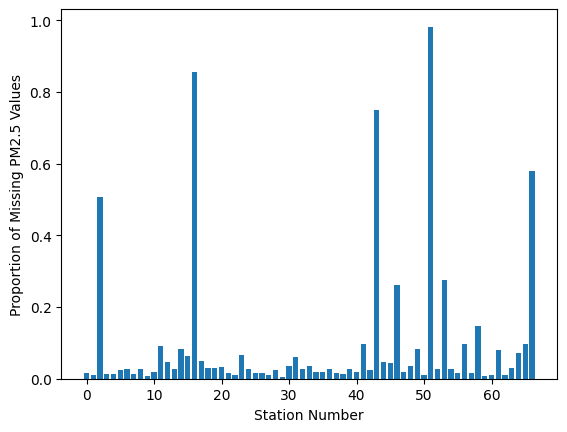

In [9]:
# find nans in each station
nans_list = []
station_names = []
for station_name, station_data in station_groups.items():
    nans = station_data.isna().sum()['PM25']/len(station_data)
    station_names.append(station_name)
    nans_list.append(nans)
        
plt.bar(np.arange(len(nans_list)), nans_list)
plt.xlabel('Station Number') 
plt.ylabel('Proportion of Missing PM2.5 Values')

In [10]:
# drop stations with more than 50% missing values
stations_to_keep = [station_name for station_name, nans in zip(station_names, nans_list) if nans <= 0.2]
cleaned_data = BCdata[BCdata['Station'].isin(stations_to_keep)].reset_index(drop=True)
print(f"Number of stations after cleaning: {len(stations_to_keep)}")

cleaned_station_groups = {}
for station_name, station_data in cleaned_data.groupby('Station'):
    cleaned_station_groups[station_name] = station_data

Number of stations after cleaning: 60


## 3. BC Air Zone

In [11]:
cleaned_data.head()

,PM25,PM25_method,PM25_n_sources,Station,datetime
0,1.4,PM25,1,Abbotsford_A_Columbia_Street,2021-12-31 00:00:00
1,2.8,PM25,1,Abbotsford_A_Columbia_Street,2022-01-01 01:00:00
2,1.6,PM25,1,Abbotsford_A_Columbia_Street,2022-01-01 02:00:00
3,3.6,PM25,1,Abbotsford_A_Columbia_Street,2022-01-01 03:00:00
4,1.8,PM25,1,Abbotsford_A_Columbia_Street,2022-01-01 04:00:00


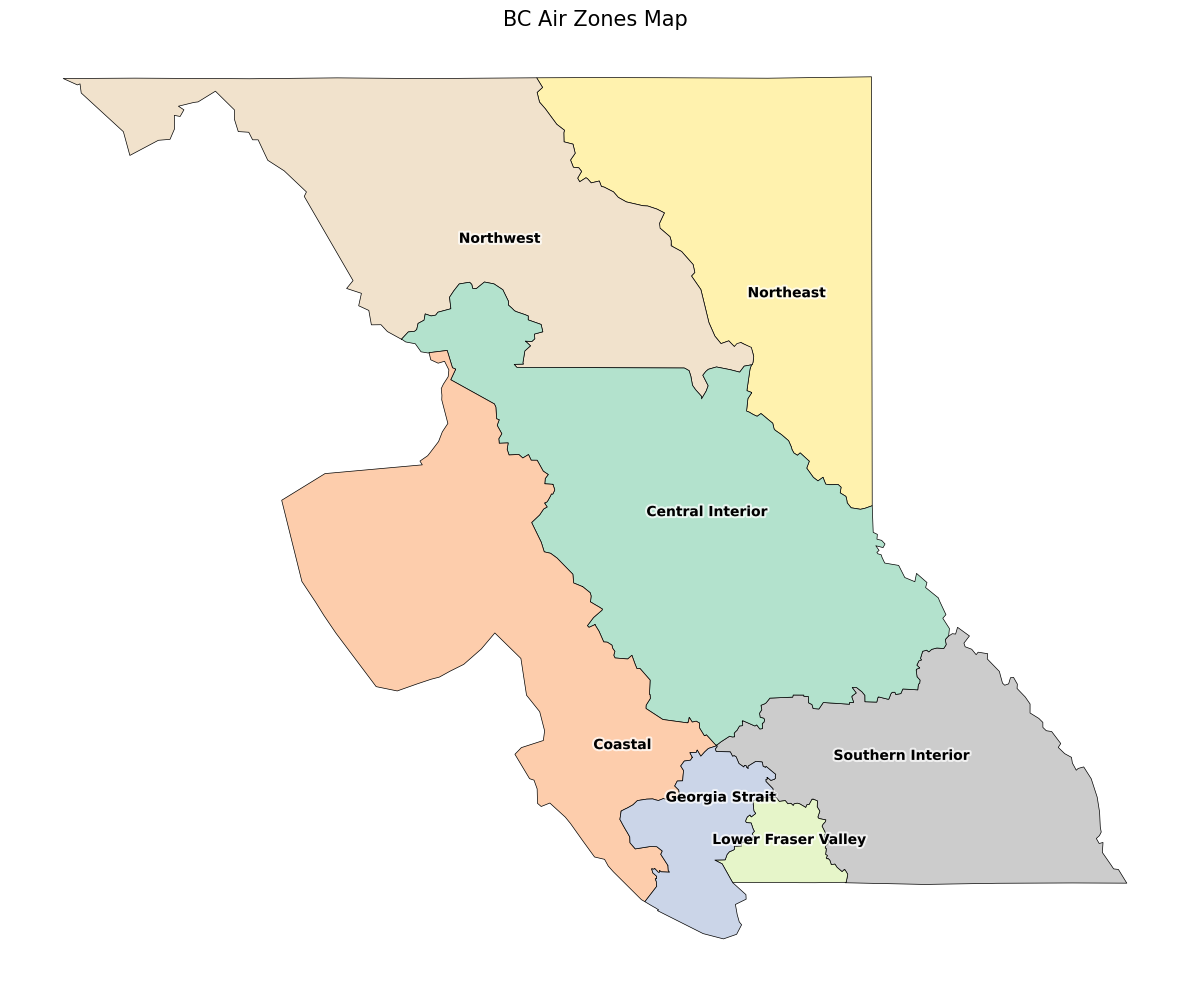

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe  

try:
    gdf = gpd.read_file("./bcairzones.geojson")
except:
    print("file DNE")
    gdf = None

if gdf is not None:
    target_column = 'Airzone' 
    if target_column not in gdf.columns:
        cols = [c for c in gdf.columns if 'zone' in c.lower() or 'name' in c.lower()]
        target_column = cols[0] if cols else gdf.columns[0]

    fig, ax = plt.subplots(figsize=(12, 12))

    gdf.plot(
        ax=ax,
        column=target_column,
        cmap='Pastel2',
        edgecolor='black',
        linewidth=0.5,
        legend=False
    )

    for idx, row in gdf.iterrows():
        xy = row.geometry.representative_point().coords[0]
        text = row[target_column]
        
        ax.annotate(
            text=text,
            xy=xy,
            xytext=(0, 0),
            textcoords="offset points",
            ha='center',
            va='center',
            fontsize=10,
            fontweight='bold',
            color='black',
            path_effects=[pe.withStroke(linewidth=3, foreground='white', alpha=0.7)]
        )

    ax.set_axis_off()
    plt.title("BC Air Zones Map", fontsize=15)
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
from fuzzywuzzy import process


my_stations = stations_to_keep
df_my_list = pd.DataFrame(my_stations, columns=['My_Station_Name'])

url = "https://www.env.gov.bc.ca/epd/bcairquality/aqo/csv/bc_air_monitoring_stations.csv"
try:
    df_official = pd.read_csv(url)

    df_official = df_official[['STATION_NAME', 'LATITUDE', 'LONGITUDE']]
except:
    df_official = pd.DataFrame({
        'STATION_NAME': ['Burnaby South Secondary', 'Victoria Topaz', 'Nanaimo Labieux Road', 'Kelowna Okanagan College'],
        'LATITUDE': [49.21, 48.44, 49.18, 49.86],
        'LONGITUDE': [-122.95, -123.36, -123.96, -119.48]
    })


def find_best_match(name, choices):

    match, score = process.extractOne(name, choices)
    
    if score >= 80: 
        return match, score
    else:
        return None, score

official_names = df_official['STATION_NAME'].tolist()

df_my_list[['Official_Name', 'Match_Score']] = df_my_list['My_Station_Name'].apply(
    lambda x: pd.Series(find_best_match(x, official_names))
)

df_final = pd.merge(
    df_my_list, 
    df_official, 
    left_on='Official_Name', 
    right_on='STATION_NAME', 
    how='left'
)

print("=== 匹配结果 ===")
print(df_final[['My_Station_Name', 'Official_Name', 'LATITUDE', 'LONGITUDE', 'Match_Score']])

print("\n=== 未匹配成功的站点 ===")
print(df_final[df_final['Official_Name'].isnull()])

=== 匹配结果 ===
                             My_Station_Name  \
0               Abbotsford_A_Columbia_Street   
1                         Abbotsford_Central   
2                    Burnaby_Kensington_Park   
3                              Burnaby_South   
4                     Burns_Lake_Fire_Centre   
5                       Castlegar_Zinio_Park   
6                         Chilliwack_Airport   
7                          Colwood_City_Hall   
8                Courtenay_Elementary_School   
9                    Cranbrook_Muriel_Baxter   
10                        Crofton_Elementary   
11                        Crofton_Substation   
12                     Duncan_College_Street   
13                      Duncan_Deykin_Avenue   
14                         Elk_Falls_Dogwood   
15                  Fort_St_John_85th_Avenue   
16          Fort_St_John_Key_Learning_Centre   
17                 Fort_St_John_North_Camp_C   
18                     Fort_St_John_Old_Fort   
19                         

Total stations attempting to match: 60
Successfully matched and ready to plot: 53


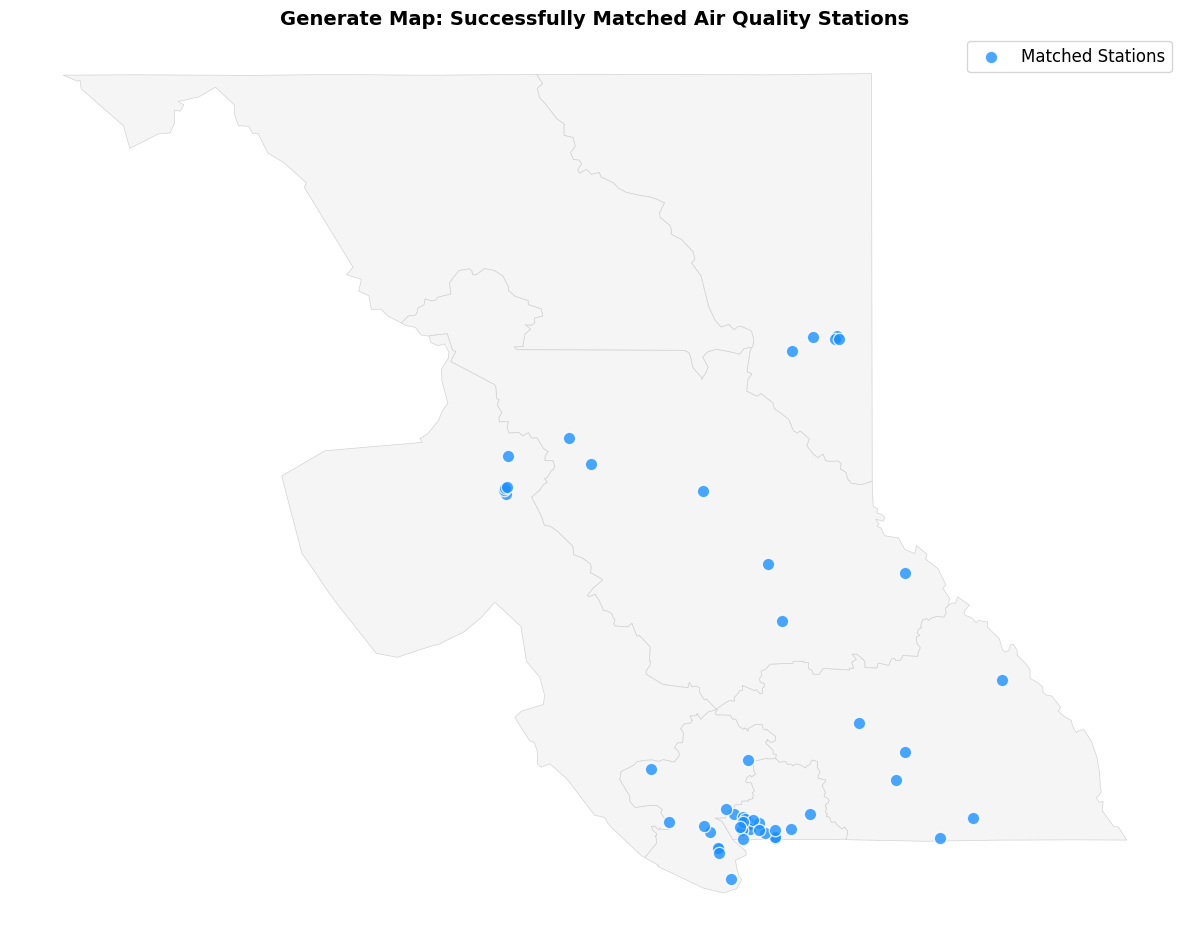

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

df_plot = df_final.dropna(subset=['LATITUDE', 'LONGITUDE']).copy()

print(f"Total stations attempting to match: {len(df_final)}")
print(f"Successfully matched and ready to plot: {len(df_plot)}")

if len(df_plot) == 0:
    print("No stations available for plotting! Please check the matching logic.")
    exit()


gdf_matched = gpd.GeoDataFrame(
    df_plot,
    geometry=gpd.points_from_xy(df_plot.LONGITUDE, df_plot.LATITUDE),
    crs="EPSG:4326"
)


base_map_loaded = False

zones_path = "bcairzones.geojson" 
gdf_zones = gpd.read_file(zones_path)
base_map_loaded = True


fig, ax = plt.subplots(figsize=(12, 12), dpi=100)


if base_map_loaded:
    gdf_zones.plot(
        ax=ax,
        color='whitesmoke',  
        edgecolor='lightgrey', 
        linewidth=0.5
    )

gdf_matched.plot(
    ax=ax,              
    color='dodgerblue', 
    markersize=80,       
    marker='o',         
    edgecolor='white',   
    linewidth=1,
    alpha=0.8,          
    label='Matched Stations' 
)


ax.set_title('Generate Map: Successfully Matched Air Quality Stations', fontsize=14, fontweight='bold')


ax.set_axis_off()


plt.legend(loc='upper right', fontsize=12)


plt.tight_layout()
plt.show()

In [53]:
import geopandas as gpd
import pandas as pd


df_clean = df_plot[['My_Station_Name', 'Official_Name', 'LATITUDE', 'LONGITUDE']].drop_duplicates().reset_index(drop=True)


zones_path = "bcairzones.geojson"
try:
    gdf_zones = gpd.read_file(zones_path).to_crs("EPSG:3005")
except Exception as e:
    print(f"map loading fail: {e}")
    exit()


df_clean['temp_id'] = range(len(df_clean))

gdf_stations = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean.LONGITUDE, df_clean.LATITUDE),
    crs="EPSG:4326"
).to_crs("EPSG:3005")



joined = gpd.sjoin_nearest(
    gdf_stations, 
    gdf_zones, 
    how="left", 
    distance_col="dist_error_m"
)

joined_unique = joined.sort_values(['temp_id', 'dist_error_m']).drop_duplicates(subset=['temp_id'], keep='first')


target_col = 'Airzone' if 'Airzone' in joined_unique.columns else joined_unique.columns[-2] 

final_df = pd.merge(
    df_clean, 
    joined_unique[['temp_id', target_col, 'dist_error_m']], 
    on='temp_id', 
    how='left'
)


final_df = final_df.drop(columns=['temp_id'])
final_df = final_df.rename(columns={target_col: 'Air_Zone'})


print("\n=== testify ===")
print(final_df[['My_Station_Name', 'Air_Zone', 'dist_error_m']].head(10))

print("\n-----")
check_list = ['Abbotsford_Central', 'Tsawwassen', 'Valemount']
print(final_df[final_df['My_Station_Name'].isin(check_list)][['My_Station_Name', 'Air_Zone', 'dist_error_m']])


=== testify ===
                My_Station_Name             Air_Zone  dist_error_m
0  Abbotsford_A_Columbia_Street  Lower Fraser Valley      0.000000
1            Abbotsford_Central  Lower Fraser Valley      0.000000
2       Burnaby_Kensington_Park  Lower Fraser Valley      0.000000
3                 Burnaby_South  Lower Fraser Valley      0.000000
4          Castlegar_Zinio_Park    Southern Interior      0.000000
5            Chilliwack_Airport  Lower Fraser Valley      0.000000
6            Crofton_Elementary  Lower Fraser Valley  28733.673992
7            Crofton_Substation  Lower Fraser Valley  28482.601774
8          Duncan_Deykin_Avenue       Georgia Strait  30984.543888
9             Elk_Falls_Dogwood       Georgia Strait  14151.559537

-----
       My_Station_Name             Air_Zone  dist_error_m
1   Abbotsford_Central  Lower Fraser Valley           0.0
44          Tsawwassen  Lower Fraser Valley           0.0
45           Valemount     Central Interior           0.0


In [25]:
final_df

,My_Station_Name,Official_Name,LATITUDE,LONGITUDE,Air_Zone,dist_error_m
0,Abbotsford_A_Columbia_Street,Abbotsford A Columbia Street,49.021500,-122.326500,Lower Fraser Valley,0.000000
1,Abbotsford_Central,Abbotsford Central,49.042600,-122.309800,Lower Fraser Valley,0.000000
2,Burnaby_Kensington_Park,Burnaby Kensington Park,49.279200,-122.970700,Lower Fraser Valley,0.000000
3,Burnaby_South,Burnaby South,49.215200,-122.985700,Lower Fraser Valley,0.000000
4,Castlegar_Zinio_Park,Castlegar Zinio Park,49.317698,-117.661527,Southern Interior,0.000000
5,Chilliwack_Airport,Chilliwack Airport,49.155800,-121.940300,Lower Fraser Valley,0.000000
6,Crofton_Elementary,Crofton Elementary,48.860000,-123.643889,Georgia Strait,28733.673992
7,Crofton_Substation,Crofton Substation,48.874529,-123.653929,Georgia Strait,28482.601774
8,Duncan_Deykin_Avenue,Duncan Deykin Avenue,48.802550,-123.646402,Georgia Strait,30984.543888
9,Elk_Falls_Dogwood,Elk Falls Dogwood,50.018425,-125.248400,Georgia Strait,14151.559537


In [54]:

correction_list = ['Nanaimo_Labieux_Road', 'Crofton_Elementary', 'Crofton_Substation', 'Harmac_Cedar_Woobank', 'Whistler_Meadow_Park']

final_df.loc[final_df['My_Station_Name'].isin(correction_list), 'Air_Zone'] = 'Georgia Strait'


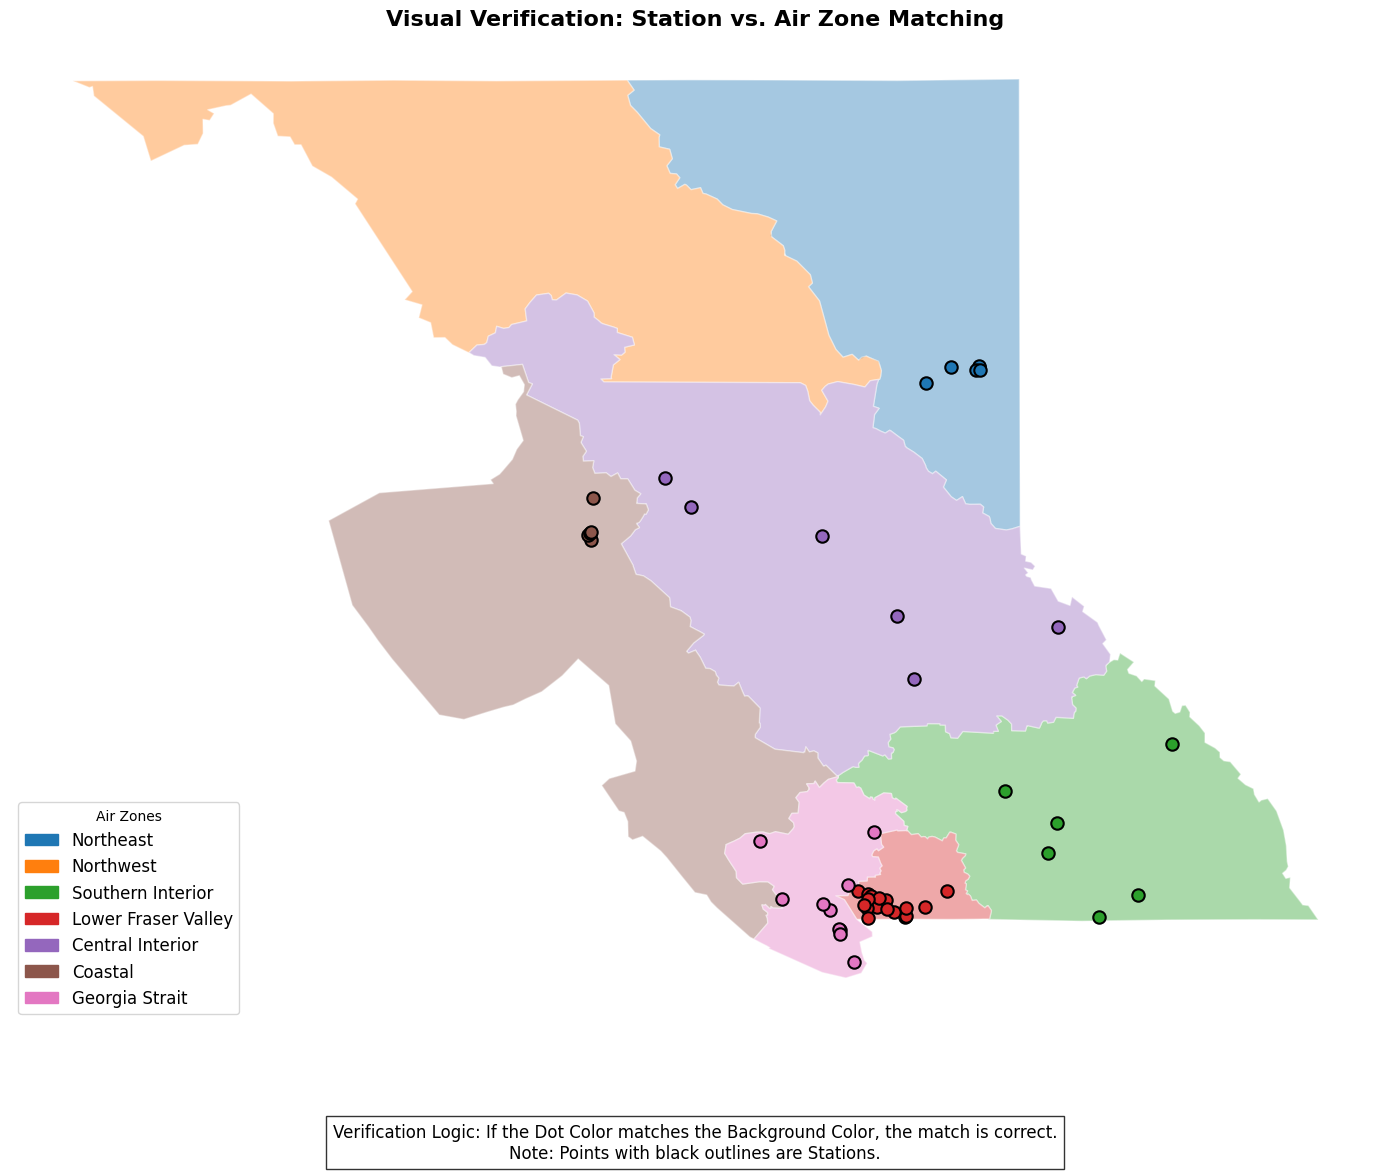

In [55]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


zones_path = "bcairzones.geojson"
gdf_zones = gpd.read_file(zones_path)


zone_col_name = [c for c in gdf_zones.columns if 'zone' in c.lower() or 'name' in c.lower()][0]

gdf_stations_final = gpd.GeoDataFrame(
    final_df,
    geometry=gpd.points_from_xy(final_df.LONGITUDE, final_df.LATITUDE),
    crs="EPSG:4326"
)


unique_zones = gdf_zones[zone_col_name].unique()


cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in range(len(unique_zones))]


zone_color_map = dict(zip(unique_zones, colors))


fig, ax = plt.subplots(figsize=(14, 14))


for zone_name in unique_zones:

    zone_geom = gdf_zones[gdf_zones[zone_col_name] == zone_name]
    

    zone_geom.plot(
        ax=ax,
        color=zone_color_map[zone_name],
        alpha=0.4,          
        edgecolor='white'   
    )


legend_handles = []

for zone_name in unique_zones:

    stations_in_zone = gdf_stations_final[gdf_stations_final['Air_Zone'] == zone_name]
    
    if len(stations_in_zone) > 0:
        stations_in_zone.plot(
            ax=ax,
            color=zone_color_map[zone_name], 
            marker='o',
            markersize=80,
            edgecolor='black', 
            linewidth=1.5,
            alpha=1.0,         
            label=zone_name
        )
        
    patch = mpatches.Patch(color=zone_color_map[zone_name], label=zone_name)
    legend_handles.append(patch)


ax.set_title("Visual Verification: Station vs. Air Zone Matching", fontsize=16, fontweight='bold')
ax.set_axis_off()


plt.legend(handles=legend_handles, title="Air Zones", loc='lower left', fontsize=12)


plt.figtext(0.5, 0.05, 
            "Verification Logic: If the Dot Color matches the Background Color, the match is correct.\n"
            "Note: Points with black outlines are Stations.", 
            ha="center", fontsize=12, bbox={"facecolor":"white", "alpha":0.8, "pad":5})

plt.tight_layout()
plt.show()

In [ ]:
'''
traitor_by_lat = final_df[
    (final_df['Air_Zone'] == 'Lower Fraser Valley') & 
    (final_df['LATITUDE'] > 49.95) # 留一点点缓冲给 border 附近的站(如 Abbotsford 49.02)
]

print(traitor_by_lat[['My_Station_Name', 'Official_Name', 'Air_Zone', 'LATITUDE', 'LONGITUDE']])
'''

=== 纬度侦测结果 ===
         My_Station_Name         Official_Name             Air_Zone  \
51  Whistler_Meadow_Park  Whistler Meadow Park  Lower Fraser Valley   

     LATITUDE   LONGITUDE  
51  50.144285 -122.960402  


In [48]:
cleaned_data.head()

,PM25,PM25_method,PM25_n_sources,Station,datetime
0,1.4,PM25,1,Abbotsford_A_Columbia_Street,2021-12-31 00:00:00
1,2.8,PM25,1,Abbotsford_A_Columbia_Street,2022-01-01 01:00:00
2,1.6,PM25,1,Abbotsford_A_Columbia_Street,2022-01-01 02:00:00
3,3.6,PM25,1,Abbotsford_A_Columbia_Street,2022-01-01 03:00:00
4,1.8,PM25,1,Abbotsford_A_Columbia_Street,2022-01-01 04:00:00


data entries: 1858496


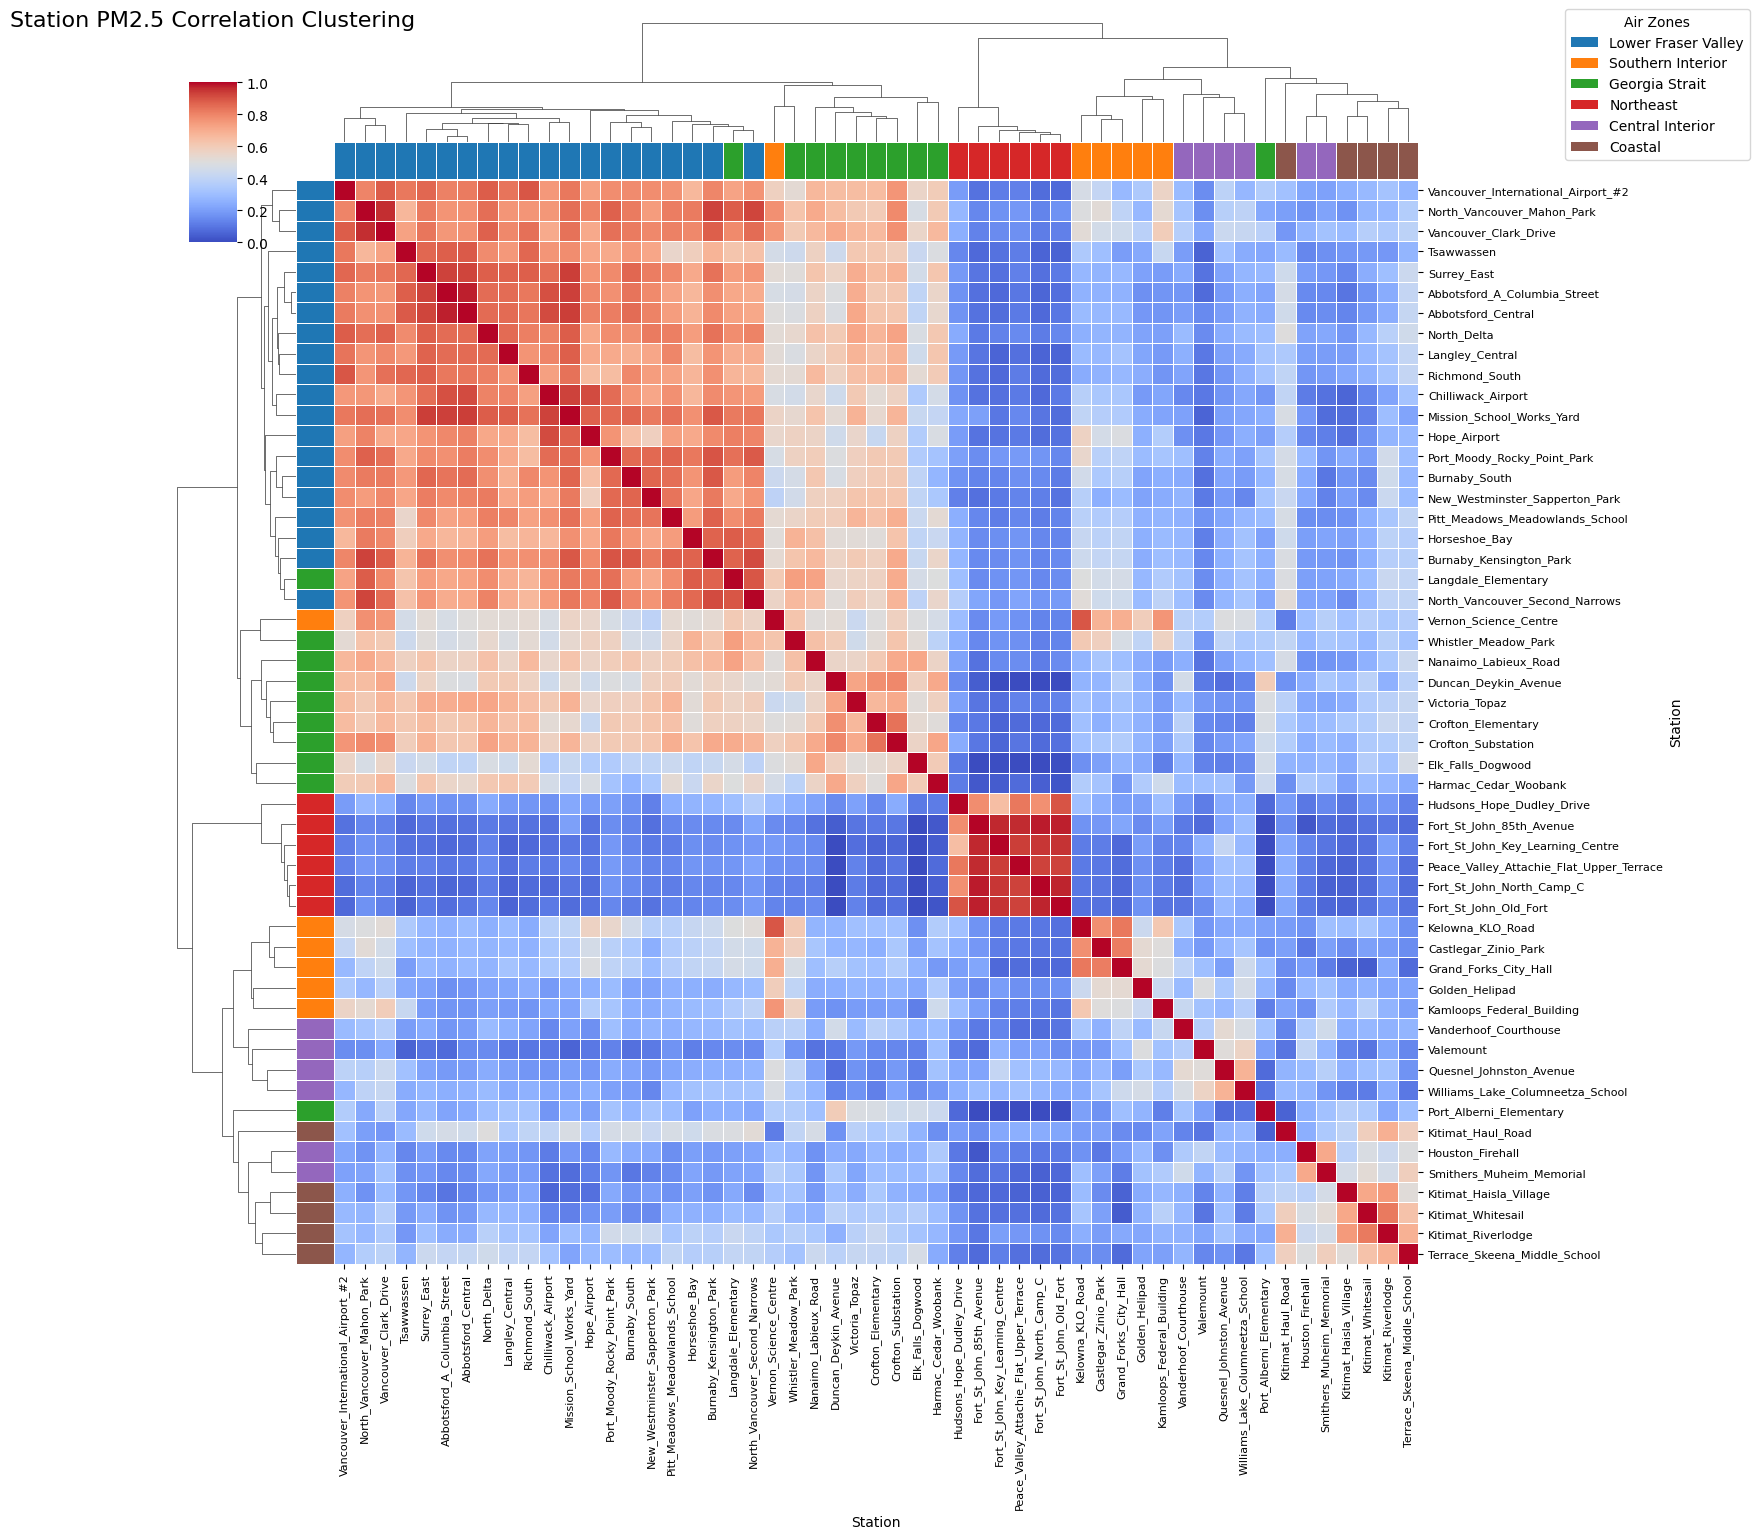

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cleaned_data['datetime'] = pd.to_datetime(cleaned_data['datetime'])


df_merged = pd.merge(
    cleaned_data, 
    final_df[['My_Station_Name', 'Air_Zone']], 
    left_on='Station', 
    right_on='My_Station_Name', 
    how='inner'
)

print(f"data entries: {len(df_merged)}")


df_pivot = df_merged.pivot_table(
    index='datetime', 
    columns='Station', 
    values='PM25'
)

df_daily = df_pivot.resample('D').mean()


corr_matrix = df_daily.corr(min_periods=30)


corr_matrix = corr_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')


unique_zones = df_merged['Air_Zone'].unique()

lut = dict(zip(unique_zones, sns.color_palette("tab10", len(unique_zones))))


site_zones = final_df.set_index('My_Station_Name')['Air_Zone']
row_colors = corr_matrix.columns.map(lambda s: lut.get(site_zones.get(s)))



g = sns.clustermap(
    corr_matrix,
    
    row_colors=row_colors,    
    col_colors=row_colors,    
    
    cmap="coolwarm",          
    vmin=0, vmax=1,           
    center=0.5,
    
    figsize=(16, 16),         
    dendrogram_ratio=(.1, .1),
    cbar_pos=(0.02, 0.85, 0.03, 0.10), 
    
    linewidths=0.5,          
    linecolor='white',
    xticklabels=True,         
    yticklabels=True
)


g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize=8)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize=8)

from matplotlib.patches import Patch
handles = [Patch(facecolor=lut[name]) for name in lut]
plt.legend(handles, lut, title='Air Zones', bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper right')

plt.title("Station PM2.5 Correlation Clustering", y=1.3, fontsize=16)
plt.show()

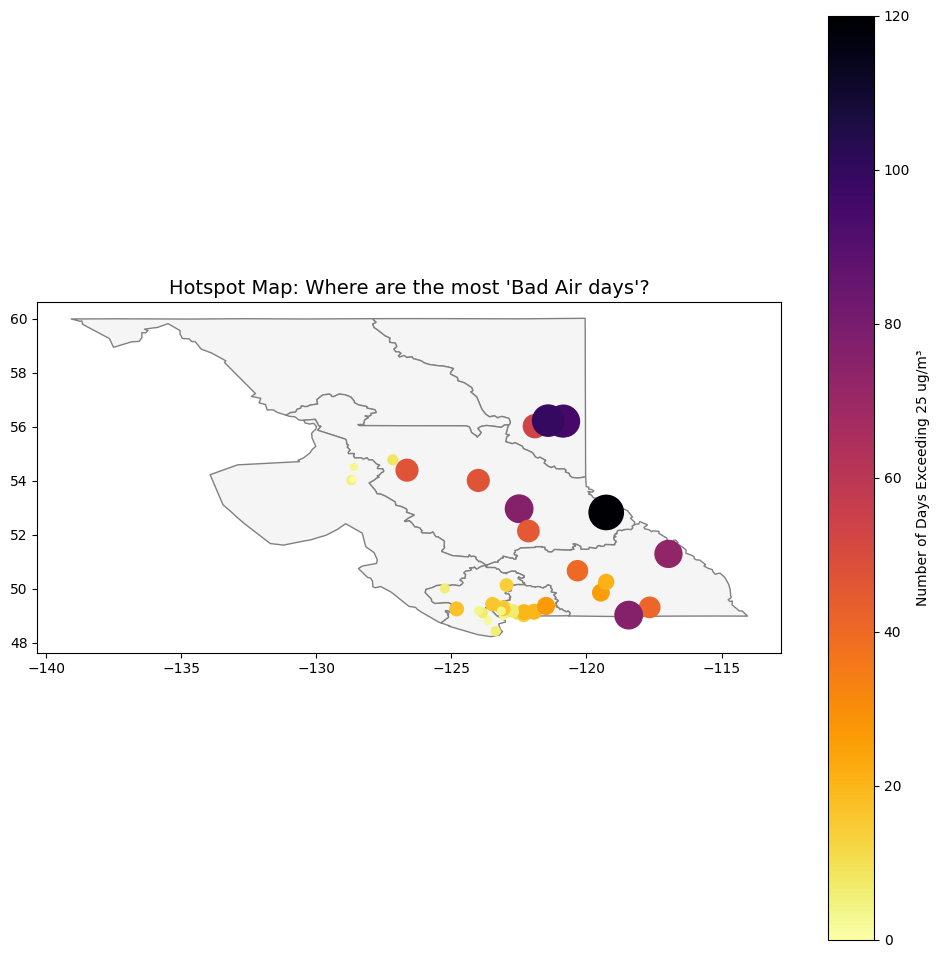

In [57]:

daily_avg = cleaned_data.set_index('datetime').groupby('Station').resample('D')['PM25'].mean().reset_index()
exceedances = daily_avg[daily_avg['PM25'] > 25].groupby('Station').size().reset_index(name='Bad_Days')


gdf_bad = pd.merge(final_df, exceedances, left_on='My_Station_Name', right_on='Station', how='left').fillna(0)
gdf_bad = gpd.GeoDataFrame(gdf_bad, geometry=gpd.points_from_xy(gdf_bad.LONGITUDE, gdf_bad.LATITUDE))


fig, ax = plt.subplots(figsize=(12, 12))
gdf_zones.plot(ax=ax, color='whitesmoke', edgecolor='grey')

gdf_bad.plot(
    ax=ax,
    column='Bad_Days',
    cmap='inferno_r', 
    markersize=gdf_bad['Bad_Days'] * 5 + 10, 
    legend=True,
    legend_kwds={'label': "Number of Days Exceeding 25 ug/m³"}
)
ax.set_title("Hotspot Map: Where are the most 'Bad Air days'?", fontsize=14)
plt.show()